# Modelo Predictivo de Turismo Internacional — México
## XGBoost con Distribución Tweedie

---

### Objetivo del proyecto

Predecir el flujo mensual de turistas extranjeros que arriban a México
por aeropuerto, país de residencia y género.
Los datos provienen del sistema **DATATUR** de la Secretaría de Turismo
de México, período 2012–2025.

---

### Algoritmo: XGBoost con distribución Tweedie

Este modelo es una variante especializada de XGBoost que cambia
la forma en que el algoritmo mide y penaliza sus errores durante
el entrenamiento.

El XGBoost estándar minimiza el **error cuadrático medio** (MSE),
que penaliza los errores grandes de forma cuadrática. En datos
como el flujo turístico, donde hay muy pocos registros enormes
(Cancún en enero con 300,000 turistas) y muchos registros pequeños
(3 turistas de Eslovaquia en Acapulco en septiembre), el MSE
concentra demasiada atención en los valores extremos y descuida
los segmentos de volumen medio.

La distribución **Tweedie** fue diseñada exactamente para este tipo
de datos: distribuciones que tienen muchos ceros o valores pequeños
y una cola derecha pronunciada. Es el mismo tipo de distribución
que se usa en modelos de seguros de automóvil (muchos asegurados
sin accidentes, pocos con accidentes grandes) y en ventas de retail.

El parámetro `tweedie_variance_power = 1.5` controla la forma:
- Valor 1: distribución Poisson (datos de conteo puros)
- Valor 2: distribución Gamma (datos continuos positivos)
- Valor 1.5: punto intermedio, apropiado para flujo turístico

**Diferencia clave respecto al XGBoost estándar:**
Con Tweedie el target se pasa al modelo en **escala original**
(no logarítmica), porque la función de pérdida ya incorpora
internamente la transformación multiplicativa adecuada.

---

### Estrategia de entrenamiento en dos fases

```
FASE 1 — Calibración:
  Entrenamiento : 2012 – Junio 2022
  Early stopping: Julio – Diciembre 2022
  Resultado     : número óptimo de árboles (BEST_N)

FASE 2 — Modelo final:
  Entrenamiento : 2012 – 2022 completo
  Árboles       : exactamente BEST_N
  Evaluación    : 2023, 2024, 2025
```

Los años 2020 y 2021 fueron excluidos durante la limpieza de datos
por los efectos atípicos de la pandemia de COVID-19.

---

### Umbrales de evaluación

| Umbral | Interpretación |
|---|---|
| ≥ 250 turistas | Actividad mínima para planificación |
| ≥ 1,000 turistas | Rutas comercialmente activas |
| ≥ 10,000 turistas | Destinos de alta demanda |
| ≥ 100,000 turistas | Segmentos premium en temporada alta |

**Activar GPU antes de ejecutar:**
Entorno de ejecución → Cambiar tipo de entorno → T4 GPU

## 1. Configuración del entorno

Se importan las bibliotecas necesarias y se verifica la disponibilidad
de GPU. XGBoost con CUDA acelera significativamente el entrenamiento,
especialmente con miles de árboles y decenas de miles de filas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, time, os
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f'XGBoost : {xgb.__version__}')
print(f'pandas  : {pd.__version__}')

try:
    _t = xgb.XGBRegressor(device='cuda', n_estimators=3)
    _t.fit(np.random.rand(10, 3), np.random.rand(10))
    print('GPU CUDA: disponible — entrenamiento acelerado')
    DEVICE = 'cuda'
except Exception as e:
    print(f'GPU no disponible ({e})')
    print('Usando CPU — activar GPU en Entorno de ejecución → T4 GPU')
    DEVICE = 'cpu'

XGBoost : 3.2.0
pandas  : 2.2.2
GPU CUDA: disponible — entrenamiento acelerado


## 2. Carga del dataset

Se carga el dataset procesado directamente desde el repositorio.
Cada fila representa una combinación única de aeropuerto, país
de residencia del turista, género, mes y año.
La columna `Valor_Residencia` es el número de turistas de esa
combinación en ese período — la variable que el modelo predecirá.

In [2]:
URL = 'https://raw.githubusercontent.com/Montiel-Oscar/predictive-tourism-intelligence-mexico/refs/heads/main/data/model_input/dataset_para_modelo2.csv'

print('Cargando dataset...')
df = pd.read_csv(URL)
if 'Año' in df.columns:
    df = df.rename(columns={'Año': 'Ano'})

TARGET   = 'Valor_Residencia'
MESES    = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
UMBRALES = [250, 1000, 10000, 100000]

print(f'Filas cargadas     : {df.shape[0]:,}')
print(f'Columnas           : {df.shape[1]}')
print(f'Años disponibles   : {sorted(df["Ano"].unique())}')
print(f'Aeropuertos únicos : {df["Aeropuerto"].nunique()}')
print(f'Países de origen   : {df["Pais"].nunique()}')

Cargando dataset...
Filas cargadas     : 371,011
Columnas           : 23
Años disponibles   : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Aeropuertos únicos : 66
Países de origen   : 243


## 3. Ingeniería de variables

Se construyen cinco grupos de variables adicionales que enriquecen
la capacidad predictiva del modelo más allá de los rezagos básicos.

**`mes_share_aeropuerto`**: porcentaje del tráfico anual de cada
aeropuerto que llega en cada mes. Permite que el modelo entienda
que mayo en Huatulco (temporada baja, 0.9% del tráfico anual)
es estructuralmente diferente a enero en Huatulco (temporada alta,
22% del tráfico anual), más allá de lo que los rezagos puedan inferir.
Se calcula solo sobre datos hasta junio 2022 para no filtrar
información del futuro.

**`log_lag1`, `log_rolling`, `log_lag12`**: los mismos rezagos
temporales pero en escala logarítmica. Aunque con Tweedie el target
se pasa en escala original, estos rezagos en log siguen siendo
señales predictivas valiosas porque capturan relaciones
multiplicativas entre períodos.

**`ratio_lag1_lag12`**: indica si el turismo está creciendo
(valor > 1) o decreciendo (valor < 1) año contra año.
Un ratio de 1.15 significa que el mes anterior tuvo un 15%
más turistas que el mismo mes del año anterior.

**`tendencia_reciente`**: indica si en el último mes hubo
más o menos turistas que el promedio de los tres meses anteriores.
Captura aceleraciones o desaceleraciones de corto plazo.
Ambos ratios se acotan entre 0.2 y 5.0 para evitar que
valores extremos distorsionen el aprendizaje.

In [3]:
# Share mensual histórico por aeropuerto (sin filtración temporal)
df_share = df[
    (df['Ano'] < 2022) | ((df['Ano'] == 2022) & (df['MesNum'] <= 6))
].copy()

anual = (
    df_share.groupby(['Aeropuerto','Ano'])[TARGET]
    .sum().reset_index()
    .rename(columns={TARGET: 'Total_anual'})
)
mes_a = (
    df_share.groupby(['Aeropuerto','Ano','MesNum'])[TARGET]
    .sum().reset_index()
    .merge(anual, on=['Aeropuerto','Ano'])
)
mes_a['share'] = mes_a[TARGET] / mes_a['Total_anual'].clip(lower=1)
share_m = (
    mes_a.groupby(['Aeropuerto','MesNum'])['share']
    .mean().reset_index()
    .rename(columns={'share': 'mes_share_aeropuerto'})
)
df = df.merge(share_m, on=['Aeropuerto','MesNum'], how='left')
df['mes_share_aeropuerto'] = df['mes_share_aeropuerto'].fillna(1/12)

# Rezagos en escala logarítmica
df['log_lag1']    = np.log1p(df['Lag_1_mes'])
df['log_rolling'] = np.log1p(df['Rolling_3m'])
df['log_lag12']   = np.log1p(df['Lag_12_meses'])

# Ratios de tendencia (acotados entre 0.2 y 5.0)
eps = 1.0
df['ratio_lag1_lag12']   = (df['Lag_1_mes'] / (df['Lag_12_meses'] + eps)).clip(0.2, 5.0)
df['tendencia_reciente'] = (df['Lag_1_mes'] / (df['Rolling_3m']   + eps)).clip(0.2, 5.0)

if 'Años_desde_inicio' not in df.columns and 'Anos_desde_inicio' in df.columns:
    df = df.rename(columns={'Anos_desde_inicio': 'Años_desde_inicio'})

print('Variables adicionales creadas correctamente.')
print(f'Nulos nuevos: {df[["mes_share_aeropuerto","log_lag1","ratio_lag1_lag12"]].isnull().sum().sum()}')

Variables adicionales creadas correctamente.
Nulos nuevos: 0


## 4. División temporal y definición de variables

Se crean los cuatro conjuntos de datos para la estrategia en dos fases.
La diferencia crítica respecto al XGBoost estándar es el target:
con Tweedie, `y_it` y `y_ft` contienen los valores **en escala original**
(número de turistas reales), no la transformación logarítmica.
La distribución Tweedie maneja internamente la escala multiplicativa.

Los tres `assert` verifican automáticamente la integridad temporal:
si alguno falla, el notebook se detiene con un error descriptivo.

In [4]:
FEATURES = [
    # Posición en el calendario
    'MesNum', 'mes_sin', 'mes_cos', 'Trimestre',
    'Es_temporada_alta', 'Años_desde_inicio',
    # Estacionalidad histórica del aeropuerto
    'mes_share_aeropuerto',
    # Identificadores codificados numéricamente
    'Sexo_enc', 'Region_enc', 'Aeropuerto_enc', 'Pais_enc', 'nac_imputada',
    # Rezagos en escala original
    'Lag_1_mes', 'Lag_2_mes', 'Lag_3_mes', 'Lag_12_meses', 'Rolling_3m',
    # Rezagos en escala logarítmica
    'log_lag1', 'log_rolling', 'log_lag12',
    # Indicadores de tendencia
    'ratio_lag1_lag12', 'tendencia_reciente'
]
FEATURES = [f for f in FEATURES if f in df.columns]

# Fase 1: calibración con early stopping
mask_it     = (df['Ano'] < 2022) | ((df['Ano'] == 2022) & (df['MesNum'] <= 6))
inner_train = df[mask_it].copy()                                    # 2012 – Jun 2022
inner_val   = df[(df['Ano'] == 2022) & (df['MesNum'] >= 7)].copy() # Jul – Dic 2022

# Fase 2: entrenamiento final
full_train  = df[df['Ano'] <= 2022].copy()   # 2012 – 2022 completo

# Validación (nunca vistos durante entrenamiento)
val23 = df[df['Ano'] == 2023].copy()
val24 = df[df['Ano'] == 2024].copy()
val25 = df[df['Ano'] == 2025].copy()

# DIFERENCIA CLAVE: Tweedie usa el target en escala ORIGINAL (no log1p)
X_it = inner_train[FEATURES]; y_it = inner_train[TARGET].values   # escala original
X_iv = inner_val[FEATURES];   y_iv = inner_val[TARGET].values     # escala original
X_ft = full_train[FEATURES];  y_ft = full_train[TARGET].values    # escala original

# Verificaciones de integridad temporal
assert inner_train['Ano'].max() <= 2022, 'Error: inner_train contiene datos de 2023+'
assert full_train['Ano'].max() == 2022,  'Error: full_train contiene datos de 2023+'
assert val23['Ano'].min() > full_train['Ano'].max(), 'Error: overlap entre train y val23'

print(f'Variables del modelo             : {len(FEATURES)}')
print(f'\nFase 1 — inner train (2012-Jun22): {len(inner_train):,} filas')
print(f'Fase 1 — inner val  (Jul-Dic22):   {len(inner_val):,} filas')
print(f'Fase 2 — full train (2012-2022):   {len(full_train):,} filas')
print(f'\nValidación 2023 (1 año) : {len(val23):,} filas')
print(f'Validación 2024 (2 años): {len(val24):,} filas')
print(f'Validación 2025 (3 años): {len(val25):,} filas')
print('\nIntegridad temporal verificada. Target en escala original (Tweedie).')

Variables del modelo             : 22

Fase 1 — inner train (2012-Jun22): 252,741 filas
Fase 1 — inner val  (Jul-Dic22):   15,058 filas
Fase 2 — full train (2012-2022):   267,799 filas

Validación 2023 (1 año) : 31,998 filas
Validación 2024 (2 años): 35,460 filas
Validación 2025 (3 años): 35,754 filas

Integridad temporal verificada. Target en escala original (Tweedie).


## 5. Fase 1 — Calibración con early stopping

El modelo entrena sobre 2012–junio 2022 y evalúa en julio–diciembre 2022.
Cuando el RMSE en ese conjunto deja de mejorar durante 200 rondas
consecutivas, el entrenamiento se detiene y se guarda el número
de árbol con el menor error como `BEST_N`.

Con `learning_rate=0.005` y hasta 20,000 árboles posibles,
el modelo aprende de forma muy gradual. Esto es intencional:
pasos pequeños producen modelos más estables y generalizables,
aunque requieren más tiempo de cómputo. La GPU compensa eso.

In [5]:
PARAMS = dict(
    objective              = 'reg:tweedie',
    tweedie_variance_power = 1.5,    # 1=Poisson, 2=Gamma, 1.5=punto intermedio
    max_depth              = 9,
    learning_rate          = 0.005,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    min_child_weight       = 10,
    gamma                  = 0.05,
    reg_alpha              = 0.1,
    reg_lambda             = 1.5,
    tree_method            = 'hist',
    device                 = DEVICE,
    random_state           = 42
)

print(f'Fase 1 — calibración Tweedie ({DEVICE.upper()})...')
print(f'  Train: 2012–Jun 2022 | Val early stopping: Jul–Dic 2022')
print(f'  Objetivo: reg:tweedie con variance_power=1.5')
t0 = time.time()

xgb_f1 = xgb.XGBRegressor(
    **PARAMS,
    n_estimators          = 20000,
    early_stopping_rounds = 200,
    eval_metric           = 'rmse'
)
xgb_f1.fit(
    X_it, y_it,
    eval_set=[(X_iv, y_iv)],
    verbose=2000
)

BEST_N = xgb_f1.best_iteration
print(f'\nFase 1 completada en {time.time()-t0:.1f}s')
print(f'Número óptimo de árboles: {BEST_N}')
print(f'RMSE mínimo en val      : {xgb_f1.best_score:.5f} (escala original, Tweedie)')

Fase 1 — calibración Tweedie (CUDA)...
  Train: 2012–Jun 2022 | Val early stopping: Jul–Dic 2022
  Objetivo: reg:tweedie con variance_power=1.5
[0]	validation_0-rmse:7674.68869
[2000]	validation_0-rmse:1634.30651
[4000]	validation_0-rmse:1579.68480
[4169]	validation_0-rmse:1579.66852

Fase 1 completada en 32.5s
Número óptimo de árboles: 3969
RMSE mínimo en val      : 1578.92715 (escala original, Tweedie)


## 6. Fase 2 — Modelo final sobre 2012-2022 completo

Se entrena el modelo definitivo con todos los datos disponibles
hasta 2022 y exactamente `BEST_N` árboles.
Al incluir julio–diciembre 2022 en el entrenamiento
(en lugar de solo hasta junio como en la Fase 1),
se añaden datos adicionales que mejoran la cobertura
de los segmentos de temporada baja en aeropuertos pequeños.

In [7]:
print(f'Fase 2 — entrenamiento final...')
print(f'  {BEST_N} árboles  |  2012–2022 completo ({len(full_train):,} filas)')
print(f'  Tweedie variance_power=1.5  |  {DEVICE.upper()}')
t0 = time.time()

xgb_final = xgb.XGBRegressor(**PARAMS, n_estimators=BEST_N)
xgb_final.fit(X_ft, y_ft)

TIEMPO = round(time.time() - t0, 1)
print(f'Completado en {TIEMPO}s')

Fase 2 — entrenamiento final...
  3969 árboles  |  2012–2022 completo (267,799 filas)
  Tweedie variance_power=1.5  |  CUDA
Completado en 30.2s


## 7. Evaluación con múltiples umbrales

Con Tweedie, `xgb_final.predict(X)` devuelve directamente
el número de turistas en escala original — no hay que aplicar
`expm1` como en el XGBoost estándar. Solo se aplica `np.maximum(..., 0)`
para garantizar que no haya predicciones negativas.

El resto de la evaluación es idéntica a los demás modelos,
lo que permite comparaciones directas y justas entre ellos.

In [8]:
def predecir(X):
    """Predice en escala original — Tweedie no requiere transformación inversa."""
    return np.maximum(xgb_final.predict(X), 0)

def evaluar(y_real, pred, nombre, umbrales=UMBRALES):
    """Calcula y reporta todas las métricas de evaluación."""
    mae    = mean_absolute_error(y_real, pred)
    rmse   = np.sqrt(mean_squared_error(y_real, pred))
    r2     = r2_score(y_real, pred)
    mape_g = np.median(np.abs((y_real - pred) / np.maximum(y_real, 1)) * 100)

    print(f"\n{'='*62}")
    print(f'  {nombre}')
    print(f"{'='*62}")
    print(f'  R²           = {r2:.4f}')
    print(f'  MAE          = {mae:>10,.1f} turistas')
    print(f'  RMSE         = {rmse:>10,.1f} turistas')
    print(f'  MAPE global  = {mape_g:.1f}%  (todos los registros, incl. segmentos pequeños)')

    mapes = {}
    for u in umbrales:
        mask   = y_real >= u
        n      = mask.sum()
        if n > 0:
            m      = np.median(np.abs((y_real[mask]-pred[mask]) / np.maximum(y_real[mask],1)) * 100)
            estado = 'DENTRO ±15%' if m <= 15 else f'a {m-15:.1f} pts del límite'
            print(f'  MAPE ≥{u:>7,} = {m:5.1f}%  (n={n:,} registros)  {estado}')
            mapes[u] = round(m, 1)
        else:
            print(f'  MAPE ≥{u:>7,} = sin registros suficientes')

    return {'r2': round(r2,4), 'mae': round(mae,1), 'rmse': round(rmse,1),
            'mape_g': round(mape_g,1), 'mapes': mapes}

pred23 = predecir(val23[FEATURES])
pred24 = predecir(val24[FEATURES])
pred25 = predecir(val25[FEATURES])

m23 = evaluar(val23[TARGET].values, pred23, 'VALIDACIÓN 2023 — 1 año de distancia')
m24 = evaluar(val24[TARGET].values, pred24, 'VALIDACIÓN 2024 — 2 años de distancia')
m25 = evaluar(val25[TARGET].values, pred25, 'VALIDACIÓN 2025 — 3 años de distancia')

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [21:13:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



  VALIDACIÓN 2023 — 1 año de distancia
  R²           = 0.9745
  MAE          =       94.8 turistas
  RMSE         =    1,111.4 turistas
  MAPE global  = 38.4%  (todos los registros, incl. segmentos pequeños)
  MAPE ≥    250 =  15.5%  (n=2,997 registros)  a 0.5 pts del límite
  MAPE ≥  1,000 =  13.7%  (n=1,589 registros)  DENTRO ±15%
  MAPE ≥ 10,000 =  13.3%  (n=273 registros)  DENTRO ±15%
  MAPE ≥100,000 =  11.1%  (n=29 registros)  DENTRO ±15%

  VALIDACIÓN 2024 — 2 años de distancia
  R²           = 0.9760
  MAE          =       91.9 turistas
  RMSE         =    1,111.5 turistas
  MAPE global  = 39.2%  (todos los registros, incl. segmentos pequeños)
  MAPE ≥    250 =  15.0%  (n=3,055 registros)  a 0.0 pts del límite
  MAPE ≥  1,000 =  13.0%  (n=1,589 registros)  DENTRO ±15%
  MAPE ≥ 10,000 =  13.9%  (n=270 registros)  DENTRO ±15%
  MAPE ≥100,000 =  11.1%  (n=35 registros)  DENTRO ±15%

  VALIDACIÓN 2025 — 3 años de distancia
  R²           = 0.9747
  MAE          =       93.2 turist

## 8. Importancia de variables

La importancia de variables en XGBoost Tweedie se interpreta igual
que en el XGBoost estándar: cuánto contribuye cada variable a
reducir el error a lo largo de todos los árboles del modelo.

Una diferencia esperada respecto al XGBoost estándar es que
Tweedie puede distribuir la importancia de forma diferente
entre los rezagos en escala original y logarítmica, dependiendo
de cuál escala el modelo encontró más informativa para predecir
la distribución Tweedie del target.

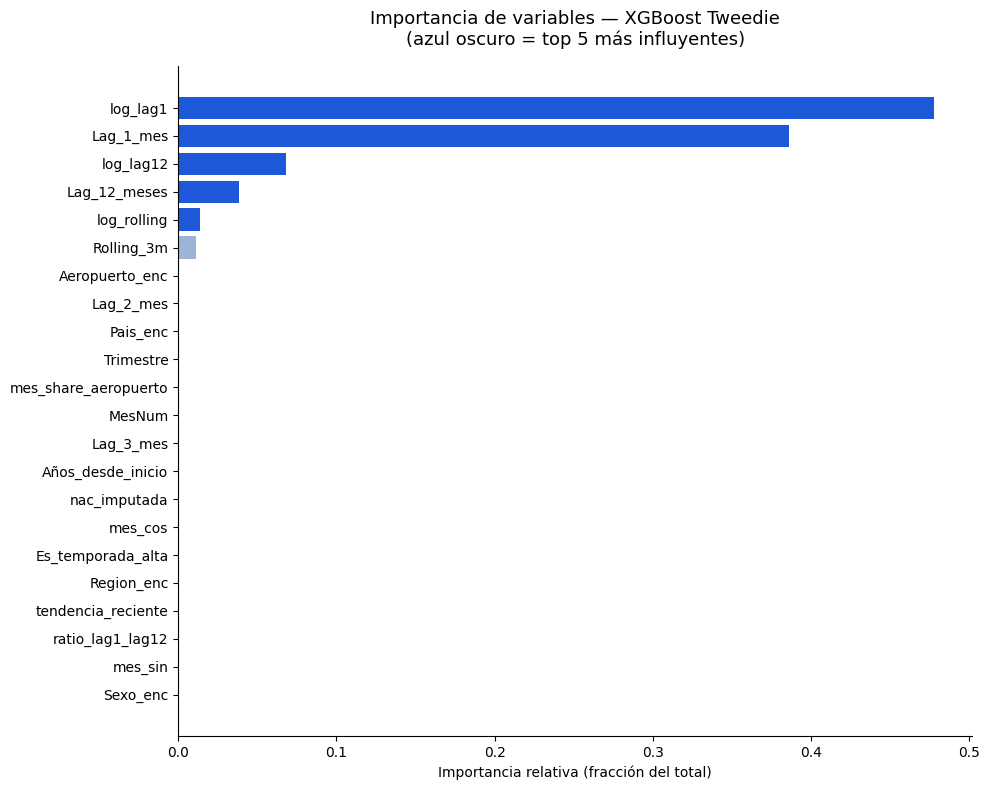

Ranking completo de variables:
  log_lag1                   47.8%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Lag_1_mes                  38.6%  ████████████████████████████████████████████████████████████████████████████████████████████████
  log_lag12                   6.8%  █████████████████
  Lag_12_meses                3.8%  █████████
  log_rolling                 1.3%  ███
  Rolling_3m                  1.1%  ██
  Aeropuerto_enc              0.1%  █
  Lag_2_mes                   0.0%  █
  Pais_enc                    0.0%  █
  Trimestre                   0.0%  █
  mes_share_aeropuerto        0.0%  █
  MesNum                      0.0%  █
  Lag_3_mes                   0.0%  █
  Años_desde_inicio           0.0%  █
  nac_imputada                0.0%  █
  mes_cos                     0.0%  █
  Es_temporada_alta           0.0%  █
  Region_enc                  0.0%  █
  tendencia_reciente          0.0%  █
  ratio

In [9]:
importancias = pd.Series(
    xgb_final.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ['#1d58d8' if i < 5 else '#9db4d6' for i in range(len(importancias))]
ax.barh(importancias.index[::-1], importancias.values[::-1],
        color=colores[::-1], edgecolor='none')
ax.set_title(
    'Importancia de variables — XGBoost Tweedie\n(azul oscuro = top 5 más influyentes)',
    fontsize=13, pad=15
)
ax.set_xlabel('Importancia relativa (fracción del total)')
plt.tight_layout()
plt.savefig('tw_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ranking completo de variables:')
for f, v in importancias.items():
    barra = '█' * max(1, int(v * 250))
    print(f'  {f:<24}  {v*100:5.1f}%  {barra}')
print(f'\nTop 5 acumulan: {importancias.head(5).sum()*100:.1f}% de la importancia total')

## 9. Diagnóstico visual

**Gráfica izquierda — Dispersión Real vs Predicho (2024):**
Si el modelo fuera perfecto, todos los puntos estarían en la
línea diagonal roja. La dispersión visible en los valores bajos
es inherente al problema: los segmentos pequeños tienen alta
variabilidad relativa que ningún modelo puede eliminar del todo.

**Gráfica derecha — Error % por mes (2024, registros ≥ 250 turistas):**
Muestra en qué meses es más difícil predecir con precisión.
Los meses de transición (temporada alta a baja o viceversa)
suelen tener mayor variabilidad histórica y por tanto
mayor error de predicción.

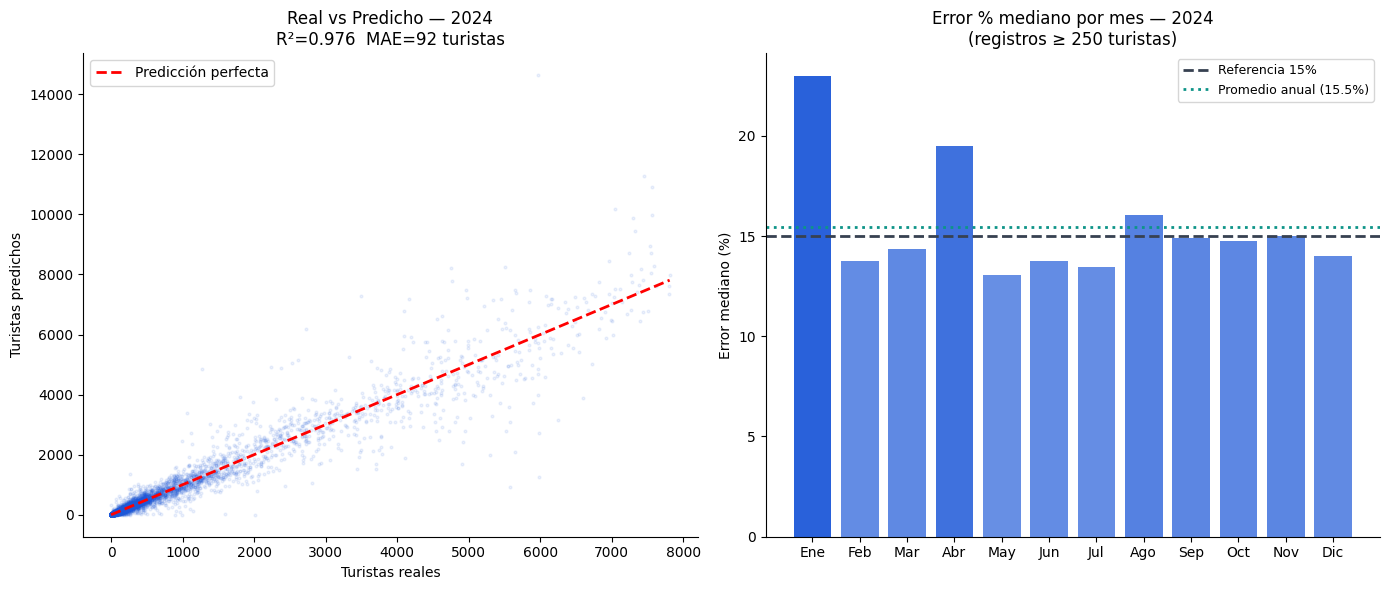

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: dispersión Real vs Predicho
y24 = val24[TARGET].values
p99 = np.percentile(y24, 99)  # omitir el 1% superior para escala legible
m99 = y24 <= p99
axes[0].scatter(y24[m99], pred24[m99], alpha=0.08, s=4, color='#1d58d8', rasterized=True)
axes[0].plot([0, p99], [0, p99], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Turistas reales')
axes[0].set_ylabel('Turistas predichos')
axes[0].set_title(f'Real vs Predicho — 2024\nR²={m24["r2"]}  MAE={m24["mae"]:,.0f} turistas')
axes[0].legend()

# Gráfica 2: error mensual
v24 = val24.copy()
v24['pred']  = pred24
v24['e_pct'] = abs(v24[TARGET] - v24['pred']) / v24[TARGET].clip(lower=1) * 100
em = v24[v24[TARGET] >= 250].groupby('MesNum')['e_pct'].median()

intens   = [0.3 + 0.65*(v/em.max()) for v in em.values]
cols_mes = [[29/255, 88/255, 216/255, a] for a in intens]
axes[1].bar(MESES, em.values, color=cols_mes, edgecolor='none')
axes[1].axhline(y=15, color='#374151', ls='--', lw=2, label='Referencia 15%')
axes[1].axhline(y=em.mean(), color='#0d9488', ls=':', lw=2,
                label=f'Promedio anual ({em.mean():.1f}%)')
axes[1].set_title('Error % mediano por mes — 2024\n(registros ≥ 250 turistas)')
axes[1].set_ylabel('Error mediano (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('tw_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Demostración — Cancún · EE.UU. · Mujeres

Comparación mes a mes entre el turismo real y el predicho
para el segmento de mayor volumen del dataset: mujeres residentes
en Estados Unidos que arriban al aeropuerto de Cancún.

Este segmento supera los 200,000 turistas en los meses pico
y es el caso de uso central para una cadena hotelera que quiera
planificar ocupación y precios con anticipación.

El gráfico cubre los tres años completos de validación (2023–2025),
todos ellos datos que el modelo nunca vio durante su entrenamiento.
El error promedio por año muestra si la precisión se mantiene
estable o se degrada conforme el modelo se aleja temporalmente
de sus datos de entrenamiento.

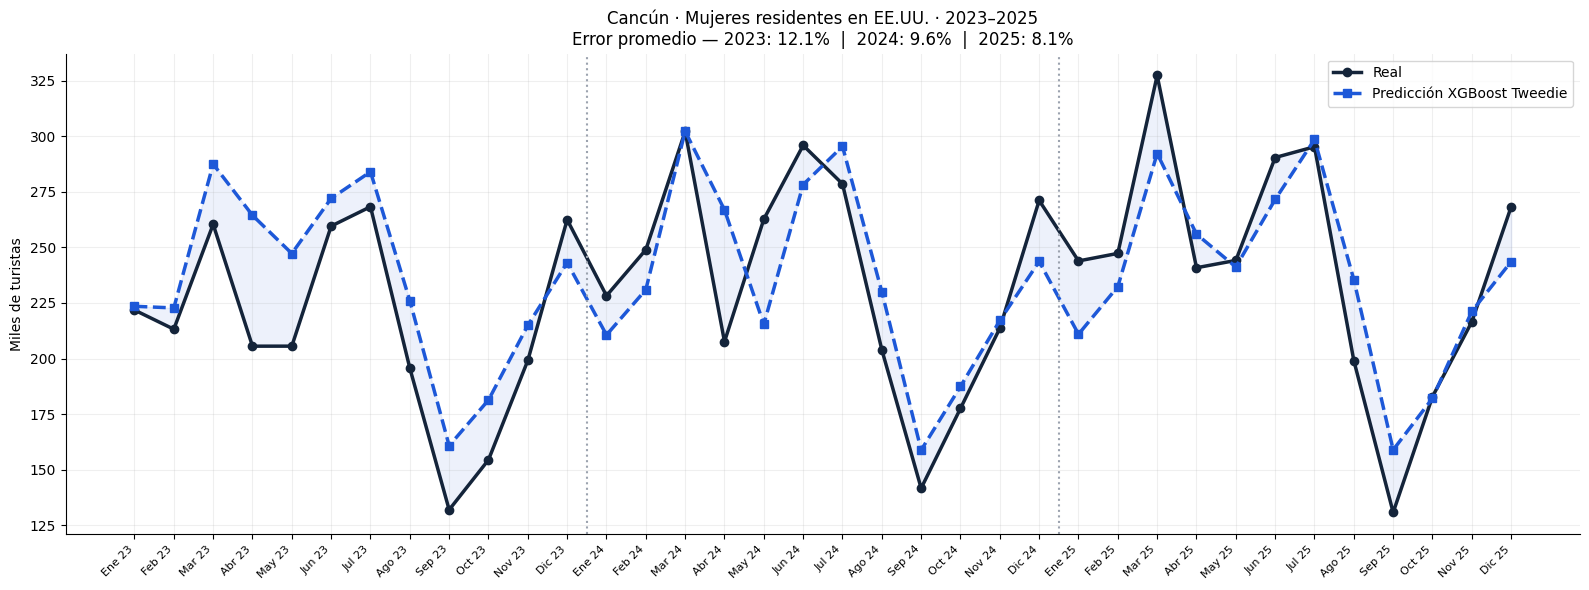

Detalle mes a mes:
   Mes  Valor_Residencia    Prediccion  Error_pct
Ene 23            221806 223501.406250        0.8
Feb 23            213190 222755.796875        4.5
Mar 23            260371 287460.281250       10.4
Abr 23            205558 264411.531250       28.6
May 23            205572 247240.687500       20.3
Jun 23            259565 272036.875000        4.8
Jul 23            268271 284001.843750        5.9
Ago 23            195684 226023.437500       15.5
Sep 23            131970 160791.312500       21.8
Oct 23            154433 181338.187500       17.4
Nov 23            199131 214947.812500        7.9
Dic 23            262450 243125.437500        7.4
Ene 24            228242 210603.281250        7.7
Feb 24            248937 230964.093750        7.2
Mar 24            302152 302242.281250        0.0
Abr 24            207580 266860.687500       28.6
May 24            262677 215410.984375       18.0
Jun 24            295894 278223.375000        6.0
Jul 24            278541 295437

In [11]:
val_todo  = pd.concat([val23, val24, val25]).copy()
pred_todo = np.concatenate([pred23, pred24, pred25])
pred_s    = pd.Series(pred_todo, index=val_todo.index)
val_todo['Prediccion'] = pred_s
val_todo['Error_pct']  = (
    abs(val_todo[TARGET] - val_todo['Prediccion']) / val_todo[TARGET] * 100
).round(1)
val_todo['Mes'] = (
    val_todo['MesNum'].map(dict(enumerate(MESES, 1))) +
    ' ' + val_todo['Ano'].astype(str).str[-2:]
)

cancun = val_todo[
    (val_todo['Aeropuerto'] == 'cancun, q. roo') &
    (val_todo['Pais']       == 'estados unidos') &
    (val_todo['Sexo']       == 'mujer')
].copy().sort_values(['Ano', 'MesNum'])

err_anio = cancun.groupby('Ano')['Error_pct'].mean()
err_str  = '  |  '.join([f'{a}: {v:.1f}%' for a, v in err_anio.items()])

fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(cancun))
ax.plot(x, cancun[TARGET]/1000,       'o-',  color='#14243a', lw=2.5, label='Real', ms=6)
ax.plot(x, cancun['Prediccion']/1000, 's--', color='#1d58d8', lw=2.5,
        label='Predicción XGBoost Tweedie', ms=6)
ax.fill_between(x, cancun[TARGET]/1000, cancun['Prediccion']/1000,
                alpha=0.08, color='#1d58d8')
for cx in [12, 24]:
    ax.axvline(x=cx-0.5, color='#9ca3af', ls=':', lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(cancun['Mes'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Miles de turistas')
ax.set_title(
    f'Cancún · Mujeres residentes en EE.UU. · 2023–2025\n'
    f'Error promedio — {err_str}',
    fontsize=12
)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tw_demo_cancun.png', dpi=150, bbox_inches='tight')
plt.show()

print('Detalle mes a mes:')
print(cancun[['Mes', TARGET, 'Prediccion', 'Error_pct']].to_string(index=False))

## 11. Tabla de resultados consolidada

Resumen final de todas las métricas para los tres años de validación.

El MAPE con umbral de 1,000 turistas es la métrica más representativa
para decisiones de negocio: un destino con menos de 1,000 turistas
mensuales de un origen específico raramente justifica inversión
en campañas de marketing o ajuste de capacidad hotelera.

Con umbrales mayores (10,000+ y 100,000+) el error disminuye
porque son los segmentos mejor representados en el entrenamiento
y con menor variabilidad relativa.

In [12]:
print('=' * 82)
print('RESULTADOS — XGBoost Tweedie')
print(f'Entrenamiento: 2012–2022  |  {len(full_train):,} observaciones  |  {len(FEATURES)} variables')
print(f'Árboles: {BEST_N}  |  lr: 0.005  |  max_depth: 9  |  Tweedie p=1.5  |  {DEVICE.upper()}')
print('=' * 82)

header = f"{'Año de validación':<18} {'R²':>8} {'MAE':>8} {'MAPE global':>12}"
for u in UMBRALES:
    header += f" {'MAPE≥'+str(u):>13}"
print(header)
print('-' * 82)

for anio, m in [('2023 (1 año)', m23), ('2024 (2 años)', m24), ('2025 (3 años)', m25)]:
    row = f"{anio:<18} {m['r2']:>8} {m['mae']:>8,.1f} {m['mape_g']:>11.1f}%"
    for u in UMBRALES:
        v = m['mapes'].get(u, None)
        row += f" {(str(v)+'%') if v else 'n/a':>13}"
    print(row)

print('=' * 82)
print(f'\nNota: MAPE global alto (~38-40%) incluye miles de registros con 1-10 turistas.')
print(f'La métrica relevante para el negocio es MAPE ≥ 1,000 turistas.')

RESULTADOS — XGBoost Tweedie
Entrenamiento: 2012–2022  |  267,799 observaciones  |  22 variables
Árboles: 3969  |  lr: 0.005  |  max_depth: 9  |  Tweedie p=1.5  |  CUDA
Año de validación        R²      MAE  MAPE global      MAPE≥250     MAPE≥1000    MAPE≥10000   MAPE≥100000
----------------------------------------------------------------------------------
2023 (1 año)         0.9745     94.8        38.4%         15.5%         13.7%         13.3%         11.1%
2024 (2 años)         0.976     91.9        39.2%         15.0%         13.0%         13.9%         11.1%
2025 (3 años)        0.9747     93.2        39.6%         14.9%         12.5%         13.5%          9.5%

Nota: MAPE global alto (~38-40%) incluye miles de registros con 1-10 turistas.
La métrica relevante para el negocio es MAPE ≥ 1,000 turistas.


## 12. Guardar modelo y predicciones

Se guardan los archivos del modelo final y sus predicciones.
Las predicciones se guardan en formato CSV con el nombre
`predicciones_xgb_mejorado.csv` para compatibilidad con
el dashboard de visualización.

In [13]:
from google.colab import files

# Guardar modelo en dos formatos
xgb_final.save_model('modelo_xgboost_tweedie.json')  # formato nativo XGBoost
with open('modelo_xgboost_tweedie.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)                         # formato Python serializado

# Predicciones de los tres años de validación
pred_out = val_todo[[
    'Ano', 'MesNum', 'Aeropuerto', 'Pais', 'Sexo',
    TARGET, 'Prediccion', 'Error_pct'
]].copy().rename(columns={'Prediccion': 'Prediccion_XGB_Mejorado'})
pred_out.to_csv('predicciones_xgb_mejorado.csv', index=False)

# Métricas en JSON para comparación con otros modelos
metricas = {
    'modelo': 'XGBoost Tweedie', 'entrenamiento': '2012-2022',
    'best_n': BEST_N, 'tweedie_variance_power': 1.5,
    'device': DEVICE, 'tiempo_s': TIEMPO, 'features': FEATURES,
    'r2_2023': m23['r2'], 'mapes_2023': m23['mapes'],
    'r2_2024': m24['r2'], 'mapes_2024': m24['mapes'],
    'r2_2025': m25['r2'], 'mapes_2025': m25['mapes'],
}
with open('metricas_xgb_tweedie.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print('=' * 58)
print('ARCHIVOS GENERADOS')
print('=' * 58)
for a in ['modelo_xgboost_tweedie.json', 'modelo_xgboost_tweedie.pkl',
          'predicciones_xgb_mejorado.csv', 'metricas_xgb_tweedie.json',
          'tw_importancia.png', 'tw_diagnostico.png', 'tw_demo_cancun.png']:
    if os.path.exists(a):
        kb = os.path.getsize(a) / 1024
        print(f'  {a:<46} {kb/1024 if kb>1024 else kb:>6.1f} {"MB" if kb>1024 else "KB"}')
        files.download(a)

print(f'\nMAPE negocio ≥ 1,000 turistas (modelo ganador):')
for anio, m in [('2023', m23), ('2024', m24), ('2025', m25)]:
    print(f'  {anio}: {m["mapes"].get(1000, "n/a")}%')

ARCHIVOS GENERADOS
  modelo_xgboost_tweedie.json                     168.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  modelo_xgboost_tweedie.pkl                       96.8 MB


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  tw_demo_cancun.png                              240.6 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


MAPE negocio ≥ 1,000 turistas (modelo ganador):
  2023: 13.7%
  2024: 13.0%
  2025: 12.5%
